In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
episode_df = pd.read_csv(r"dataset\episodes\episode_unbalanced.csv",index_col=0)
embeddings = np.load(r"dataset\embeddings\unbalanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [16]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 122


,orig_index,content_id,sentence,published_date,category,episode
0,5111,1282697,"In addition to footage of customers, the devic...",2024-02-13,Gadgets,36
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,36
2,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,36
3,5067,1284526,"According to court documents, Vargas-Fernandez...",2024-02-15,Gadgets,36
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,36


In [17]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [18]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-13 00:00:00
End: 2024-12-03 00:00:00
Duration (days): 294


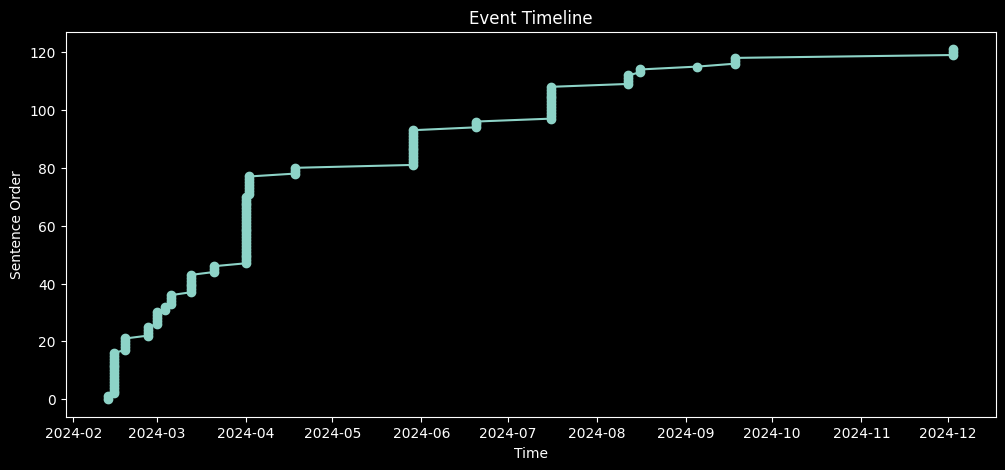

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

In [20]:
import hdbscan

In [21]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,   # minimum sentences per event
    metric='euclidean'
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [22]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,5111,1282697,"In addition to footage of customers, the devic...",2024-02-13,Gadgets,36,-1
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,36,-1
2,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,36,-1
3,5067,1284526,"According to court documents, Vargas-Fernandez...",2024-02-15,Gadgets,36,-1
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,36,-1


In [23]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 5
-1    79
 4    24
 1     5
 3     5
 0     5
 2     4
Name: event_id, dtype: int64


In [32]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    print("\n======================")
    print("Event ID:", event)
    print("======================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(3)

    for s in event_sentences:
        print("-", s)


Event ID: 0
- The detective said the video shows Selleny recording himself as he committed a sex act in her home.
- Police said Selleny, who lives in the same King of Prussia apartment complex as the victim, broke into her home “on several occasions” and planted the hidden camera.
- “Evidence collected at his apartment leads detectives to believe that there are potentially several more victims of Selleny and this type of behaviour may have been occurring for some time,” police said.

Event ID: 1
- Police believe there may be additional places where Vargas-Fernandez has placed cameras, according to court documents.
- Following his arrest, Vargas-Fernandez told police he used spy cameras to surveil his ex-wife in her home without her knowledge, according to court documents.
- A search warrant confirmed Vargas-Fernandez purchased two spy camera devices on Amazon in October that match the devices recovered, police said.

Event ID: 2
- The cameras were rediscovered and the restrooms tempor

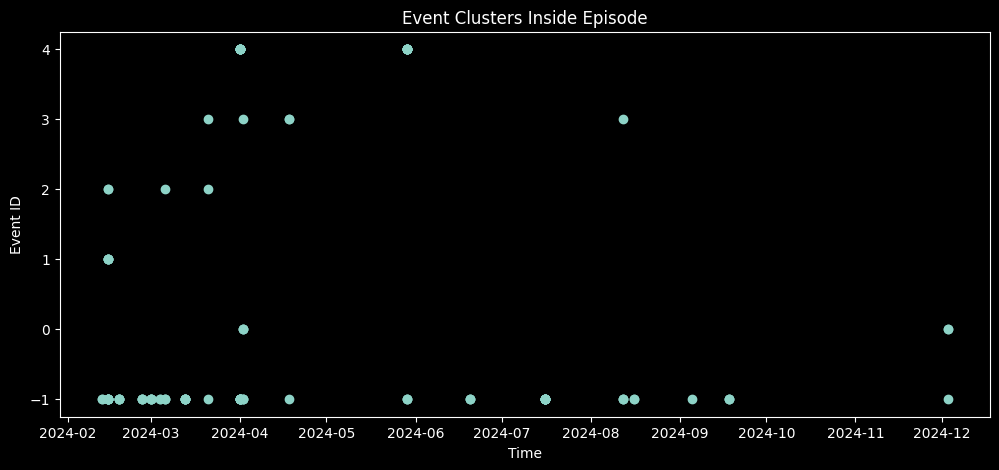

In [25]:
plt.figure(figsize=(12,5))

plt.scatter(
    episode_df["published_date"],
    episode_df["event_id"]
)

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.show()

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

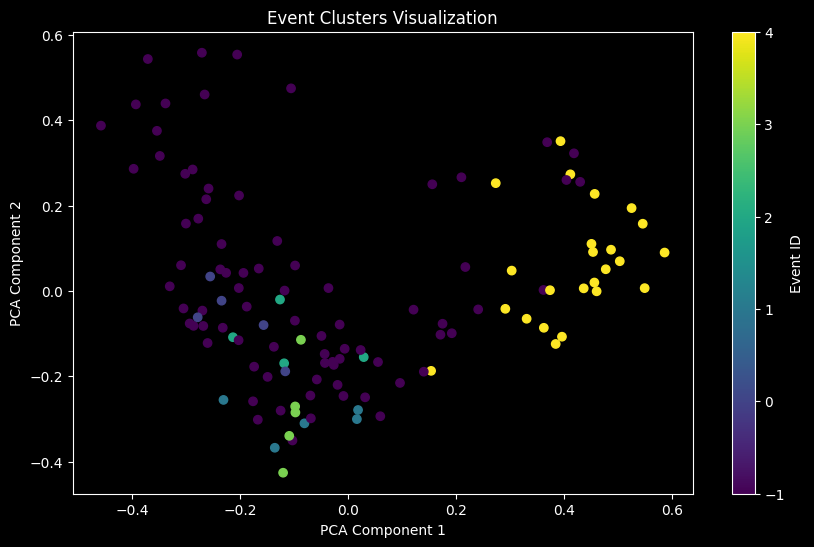

In [27]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
)

plt.title("Event Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(scatter, label="Event ID")

plt.show()